In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

TRADES_FILE = "tr5_d2.csv"
MARKET_FILE = "r5_d2.csv"
PRODUCT = "KELP"
OUTPUT_DIR = Path("KELP")
OUTPUT_DIR.mkdir(exist_ok=True)

In [ ]:
# -------------------------
# Load and filter data; test for kelp first
# -------------------------
trades = pd.read_csv(TRADES_FILE, sep=";")
market = pd.read_csv(MARKET_FILE, sep=";")

kelp_trades = trades[trades["symbol"] == PRODUCT].copy()
kelp_market = market[market["product"] == PRODUCT].copy()

# Ensure numeric timestamps / prices
kelp_trades["timestamp"] = pd.to_numeric(kelp_trades["timestamp"], errors="coerce")
kelp_trades["price"] = pd.to_numeric(kelp_trades["price"], errors="coerce")
kelp_market["timestamp"] = pd.to_numeric(kelp_market["timestamp"], errors="coerce")
kelp_market["mid_price"] = pd.to_numeric(kelp_market["mid_price"], errors="coerce")

kelp_trades = kelp_trades.dropna(subset=["timestamp", "price"])
kelp_market = kelp_market.dropna(subset=["timestamp", "mid_price"])

# -------------------------
# Extract participant list
# -------------------------
participants = sorted(set(kelp_trades["buyer"]).union(set(kelp_trades["seller"])))

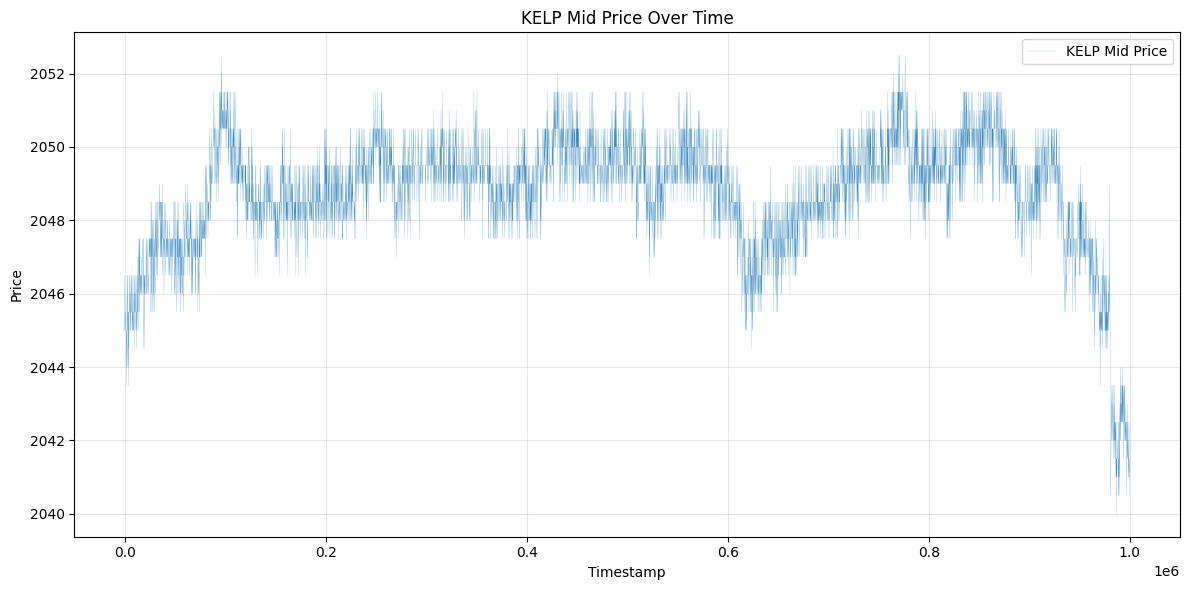

In [6]:
# -------------------------
# Baseline mid-price graph
# -------------------------
kelp_market_sorted = kelp_market.sort_values("timestamp")

plt.figure(figsize=(12, 6))
plt.plot(
    kelp_market_sorted["timestamp"],
    kelp_market_sorted["mid_price"],
    label="KELP Mid Price",
    lw=0.1
)

plt.title("KELP Mid Price Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "kelp_mid_price.png", dpi=200)
plt.show()

In [ ]:
# -------------------------
# Create one graph per participant
# -------------------------
for participant in participants:
    p_trades = kelp_trades[
        (kelp_trades["buyer"] == participant) | (kelp_trades["seller"] == participant)
    ].copy()

    if p_trades.empty:
        continue

    buys = p_trades[p_trades["buyer"] == participant]
    sells = p_trades[p_trades["seller"] == participant]

    plt.figure(figsize=(12, 6))

    # Mid-price line
    plt.plot(
        kelp_market_sorted["timestamp"],
        kelp_market_sorted["mid_price"],
        label="KELP Mid Price",
        linewidth=0.1,
    )

    # Buy dots
    if not buys.empty:
        plt.scatter(
            buys["timestamp"],
            buys["price"],
            color="green",
            label=f"{participant} Buys",
            s=35,
            alpha=0.8,
        )

    # Sell dots
    if not sells.empty:
        plt.scatter(
            sells["timestamp"],
            sells["price"],
            color="red",
            label=f"{participant} Sells",
            s=35,
            alpha=0.8,
        )

    plt.title(f"KELP Trades for {participant}")
    plt.xlabel("Timestamp")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out_file = OUTPUT_DIR / f"kelp_trades_{participant}.png"
    plt.savefig(out_file, dpi=200)
    plt.show()

print(f"Saved plots to: {OUTPUT_DIR.resolve()}")

In [ ]:
# -------------------------
# Load data; skip if kelp
# -------------------------
trades = pd.read_csv(TRADES_FILE, sep=";")
market = pd.read_csv(MARKET_FILE, sep=";")

trades["timestamp"] = pd.to_numeric(trades["timestamp"], errors="coerce")
trades["price"] = pd.to_numeric(trades["price"], errors="coerce")
market["timestamp"] = pd.to_numeric(market["timestamp"], errors="coerce")
market["mid_price"] = pd.to_numeric(market["mid_price"], errors="coerce")

trades = trades.dropna(subset=["timestamp", "price", "symbol"])
market = market.dropna(subset=["timestamp", "mid_price", "product"])

products = sorted(set(trades["symbol"]).intersection(set(market["product"])))
products = [p for p in products if p != "KELP"]

for product in products:
    product_trades = trades[trades["symbol"] == product].copy()
    product_market = market[market["product"] == product].copy()

    if product_trades.empty or product_market.empty:
        continue

    product_market = product_market.sort_values("timestamp")
    participants = sorted(set(product_trades["buyer"]).union(set(product_trades["seller"])))

    product_dir = OUTPUT_DIR / product
    product_dir.mkdir(exist_ok=True)

    # -------------------------
    # Baseline mid-price plot
    # -------------------------
    plt.figure(figsize=(12, 6))
    plt.plot(
        product_market["timestamp"],
        product_market["mid_price"],
        linewidth=0.1,
        label=f"{product} Mid Price",
    )
    plt.title(f"{product} Mid Price Over Time")
    plt.xlabel("Timestamp")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(product_dir / f"{product}_mid_price.png", dpi=200)
    plt.show()

    # -------------------------
    # Participant overlay plots
    # -------------------------
    for participant in participants:
        p_trades = product_trades[
            (product_trades["buyer"] == participant) | (product_trades["seller"] == participant)
        ].copy()

        if p_trades.empty:
            continue

        buys = p_trades[p_trades["buyer"] == participant]
        sells = p_trades[p_trades["seller"] == participant]

        plt.figure(figsize=(12, 6))

        # Mid-price line
        plt.plot(
            product_market["timestamp"],
            product_market["mid_price"],
            linewidth=0.1,
            label=f"{product} Mid Price",
        )

        # Buy dots
        if not buys.empty:
            plt.scatter(
                buys["timestamp"],
                buys["price"],
                color="green",
                s=35,
                alpha=0.8,
                label=f"{participant} Buys",
            )

        # Sell dots
        if not sells.empty:
            plt.scatter(
                sells["timestamp"],
                sells["price"],
                color="red",
                s=35,
                alpha=0.8,
                label=f"{participant} Sells",
            )

        plt.title(f"{product} Trades for {participant}")
        plt.xlabel("Timestamp")
        plt.ylabel("Price")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        out_file = product_dir / f"{product}_trades_{participant}.png"
        plt.savefig(out_file, dpi=200)
        plt.show()

print(f"Saved plots to: {OUTPUT_DIR.resolve()}")

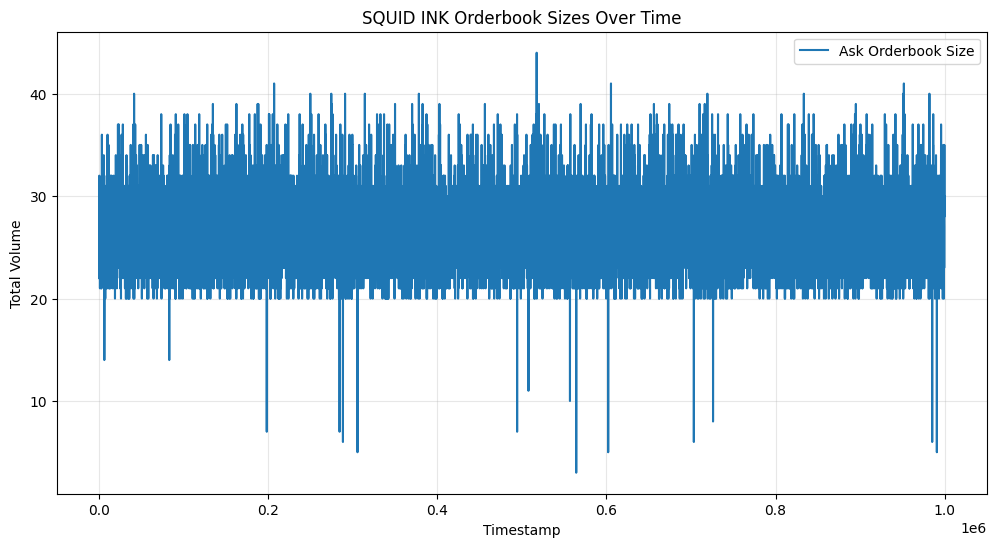

In [8]:
# SQUID INK ANALYSIS - get orderbook sizes for bids / asks

PRODUCT = "SQUID_INK"
market = pd.read_csv(MARKET_FILE, sep=";")

squid_ink_market = market[market["product"] == PRODUCT].copy()

# (1) Replace NaNs with 0 in volume columns
volume_cols = [
    "bid_volume_1", "bid_volume_2", "bid_volume_3",
    "ask_volume_1", "ask_volume_2", "ask_volume_3"
]

squid_ink_market[volume_cols] = squid_ink_market[volume_cols].fillna(0)

# Compute total orderbook sizes
bid_orderbook_size = (
    squid_ink_market["bid_volume_1"] +
    squid_ink_market["bid_volume_2"] +
    squid_ink_market["bid_volume_3"]
)

ask_orderbook_size = (
    squid_ink_market["ask_volume_1"] +
    squid_ink_market["ask_volume_2"] +
    squid_ink_market["ask_volume_3"]
)

# (2) Plot against timestamp
timestamps = squid_ink_market["timestamp"]

plt.figure(figsize=(12, 6))

# plt.plot(timestamps, bid_orderbook_size, label="Bid Orderbook Size")
plt.plot(timestamps, ask_orderbook_size, label="Ask Orderbook Size")

plt.title("SQUID INK Orderbook Sizes Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Total Volume")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()